In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Creación de data set: Ventas mensuales

In [4]:
np.random.seed(42) #Control de aleatoriedad
meses = 24
ventas = 1000 + np.arange(meses) * 50 + np.random.normal(1, 100, meses) # ventas = Base + Tendencia + Ruido

### Análisis estadístico completo - Ventas Mensuales

**Estadística Descriptiva**

In [7]:
media = np.mean(ventas) # Promedio aritmético
mediana = np.median(ventas) # Valor central
desviacion_estandar = np.std(ventas, ddof=1) # Dispersión de datos

print(f"Media: ${media:.2f}")
print(f"Mediana: ${mediana:.2f}")
print(f"Desviación estandar: ${desviacion_estandar:.2f}")

Media: $1561.24
Mediana: $1504.84
Desviación estandar: $326.10


**Análisis de tendencia (regresión)**

In [17]:
tiempo = np.arange(meses) # Lista de 0 a 23
slope, intercept, r_value, p_value, std_err = stats.linregress(tiempo, ventas) 

print(f"Tendencia: ${slope:.2f} por mes")
print(f"R2: {r_value**2:.3f}")
print(f"Crecimiento mensual: {(slope / media) * 100:.2f}%")

Tendencia: $44.37 por mes
R2: 0.926
Crecimiento mensual: 2.84%


**Prueba de normalidad (Shapiro-Wilk)**

In [18]:
stat, p_normal = stats.shapiro(ventas)

print(f"Estadístico: {stat:.4f}")
print(f"Valor p: {p_normal:.4f}")

if p_normal > 0.05: print("Los datos siguen una distribución normal")
else: print("Los datos NO siguen una distribución normal")

Estadístico: 0.9622
Valor p: 0.4852
Los datos siguen una distribución normal


### Visualización completa del análisis

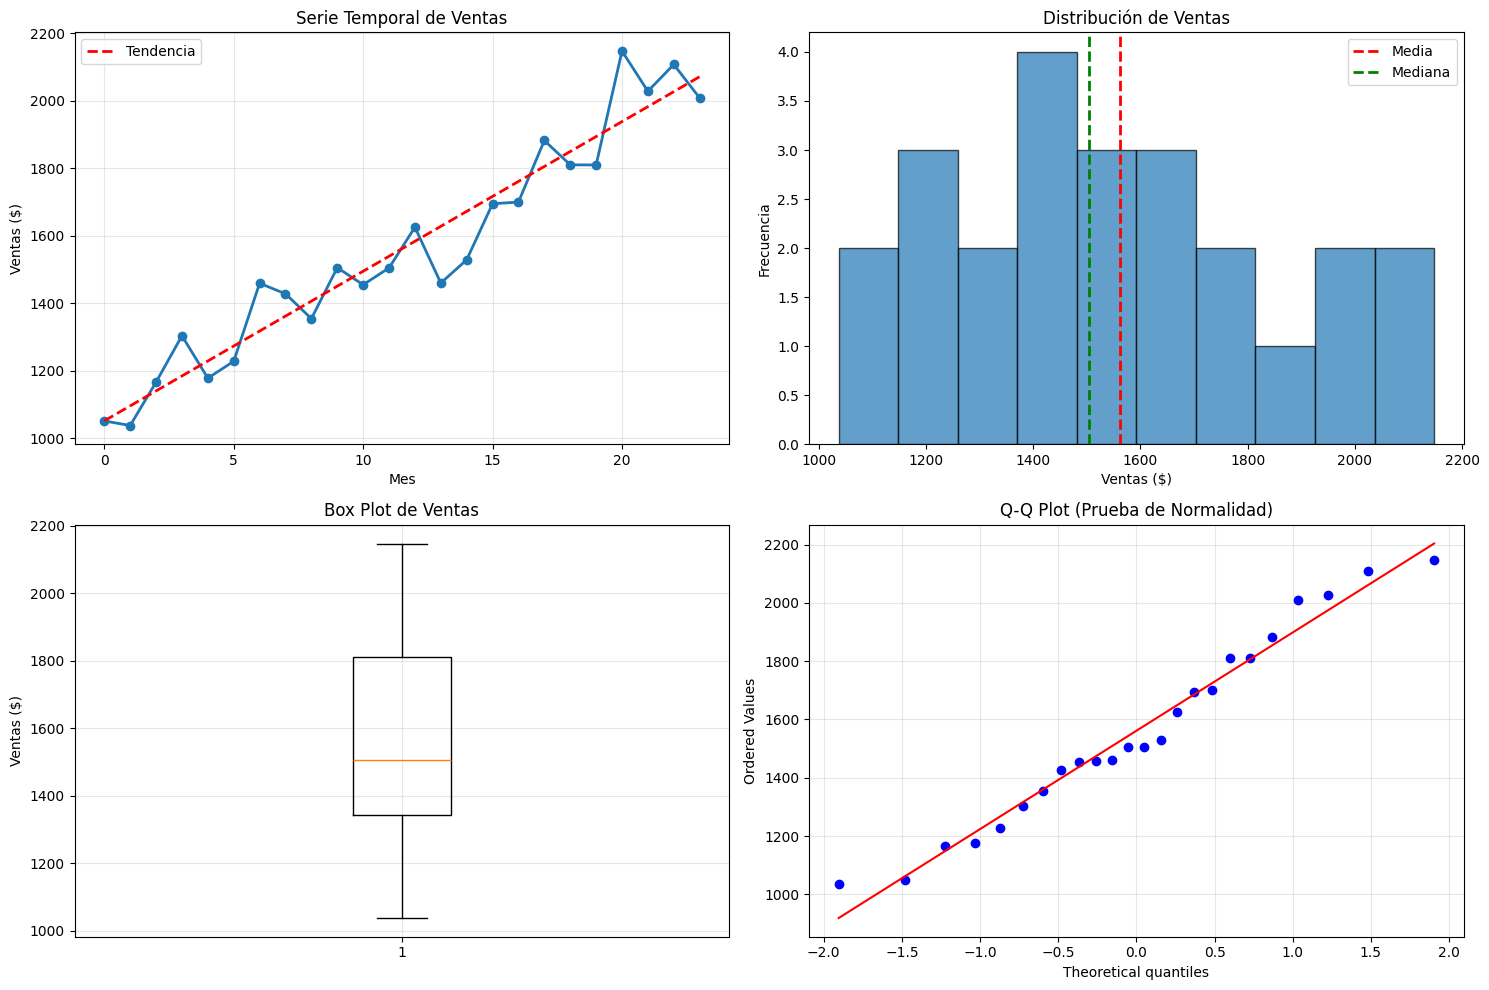

In [19]:
# Crea una cuadrícula de 2 filas y 2 columnas para mostrar 4 gráficos a la vez
# figsize=(15, 10) define el ancho y alto total de la imagen en pulgadas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- GRÁFICO 1: SERIE TEMPORAL (Arriba a la izquierda) ---
# Dibuja la línea de ventas: "o-" pone puntos en cada mes y los une con líneas
axes[0, 0].plot(tiempo, ventas, "o-", linewidth=2, markersize=6)
# Dibuja la línea de tendencia (regresión) en color rojo ("r") y discontinua ("--")
axes[0, 0].plot(
    tiempo, slope * tiempo + intercept, "r--", linewidth=2, label="Tendencia"
)
axes[0, 0].set_xlabel("Mes")            # Etiqueta el eje horizontal
axes[0, 0].set_ylabel("Ventas ($)")     # Etiqueta el eje vertical
axes[0, 0].set_title("Serie Temporal de Ventas") # Título del cuadrante
axes[0, 0].legend()                     # Muestra el cuadro con los nombres (labels)
axes[0, 0].grid(True, alpha=0.3)        # Agrega una cuadrícula tenue de fondo

# --- GRÁFICO 2: HISTOGRAMA (Arriba a la derecha) ---
# Divide los datos en 10 barras (bins) para ver cuántas veces caen las ventas en ciertos rangos
axes[0, 1].hist(ventas, bins=10, edgecolor="black", alpha=0.7)
# Dibuja una línea vertical roja para marcar dónde está el promedio (media)
axes[0, 1].axvline(
    np.mean(ventas), color="red", linestyle="--", linewidth=2, label="Media"
)
# Dibuja una línea vertical verde para marcar el punto medio de los datos (mediana)
axes[0, 1].axvline(
    np.median(ventas), color="green", linestyle="--", linewidth=2, label="Mediana"
)
axes[0, 1].set_xlabel("Ventas ($)")
axes[0, 1].set_ylabel("Frecuencia")     # Indica cuántos meses caen en cada barra
axes[0, 1].set_title("Distribución de Ventas")
axes[0, 1].legend()

# --- GRÁFICO 3: BOX PLOT / DIAGRAMA DE CAJA (Abajo a la izquierda) ---
# Muestra la dispersión, los cuartiles y detecta si hay valores atípicos (puntos fuera de los bigotes)
axes[1, 0].boxplot(ventas)
axes[1, 0].set_ylabel("Ventas ($)")
axes[1, 0].set_title("Box Plot de Ventas")
axes[1, 0].grid(True, alpha=0.3)

# --- GRÁFICO 4: Q-Q PLOT / GRÁFICO DE PROBABILIDAD (Abajo a la derecha) ---
# Compara tus datos contra una distribución normal teórica
# Si los puntos azules siguen la línea roja, tus datos son "normales"
stats.probplot(ventas, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot (Prueba de Normalidad)")
axes[1, 1].grid(True, alpha=0.3)

# Ajusta automáticamente el espacio entre los gráficos para que no se encimen los textos
plt.tight_layout()
# Despliega la figura final en pantalla
plt.show()